In [67]:
pip install hvplot

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 9.0 MB/s eta 0:00:01
   -------------------- ------------------- 3.7/7.2 MB 9.3 MB/s eta 0:00:01
   -------------------------------- ------- 5.8/7.2 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 9.3 MB/s  0:00:00
   ---------------------------------------- 0.0/5.9 MB ? eta -:--:--
   --------------- ------------------------ 2.4/5.9 MB 12.6 MB/s eta 0:00:01
   --------------------------------- ------ 5.0/5.9 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 5.9/5.9 MB 11.7 MB/s  0:00:00
   ---------------------------------------- 0.0/30.2 MB ? eta -:--:--
   --- ------------------------------------ 2.6/30.2 MB 12.9 MB/s eta 0:00:03
   ------ --------------------------------- 5.2/30.2 MB 12.7 MB/s eta 0:00:02
   ---------- ----------------------------- 8.1/30.2 MB 12.7 MB/s eta 0:00:02
   -------------- -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import 





In [3]:
df = pd.read_csv(r"C:\Users\perso\Desktop\vizuara ml\learning\datasets\Real estate.csv")

In [4]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [5]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
df.sample(10)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
76,77,2013.583,35.9,616.40040,3,24.97723,121.53767,36.8
344,345,2013.500,34.6,3085.17000,0,24.99800,121.51550,41.2
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
173,174,2013.083,41.3,401.88070,4,24.98326,121.54460,35.1
310,311,2013.583,16.4,1643.49900,2,24.95394,121.55174,24.7
108,109,2013.417,31.4,592.50060,2,24.97260,121.53561,34.1
36,37,2012.917,14.7,1935.00900,2,24.96386,121.51458,22.9
365,366,2012.917,17.3,2261.43200,4,24.96182,121.51222,29.5
393,394,2013.000,16.9,967.40000,4,24.98872,121.53408,40.3


In [7]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [29]:
df.shape

(414, 8)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [33]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


<Axes: >

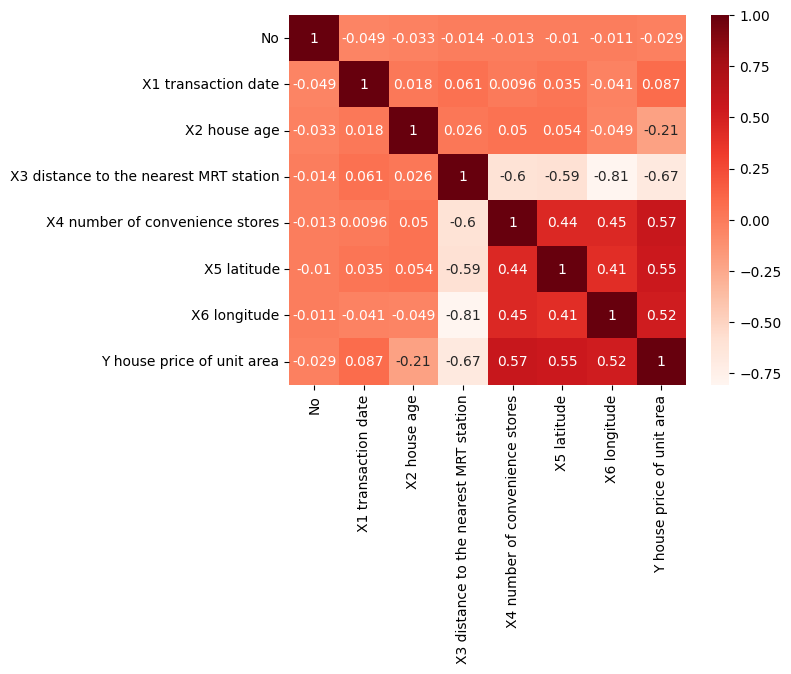

In [37]:
sns.heatmap(df.corr(),annot=True, cmap='Reds')

EDA (Exploratory Data Analysis)

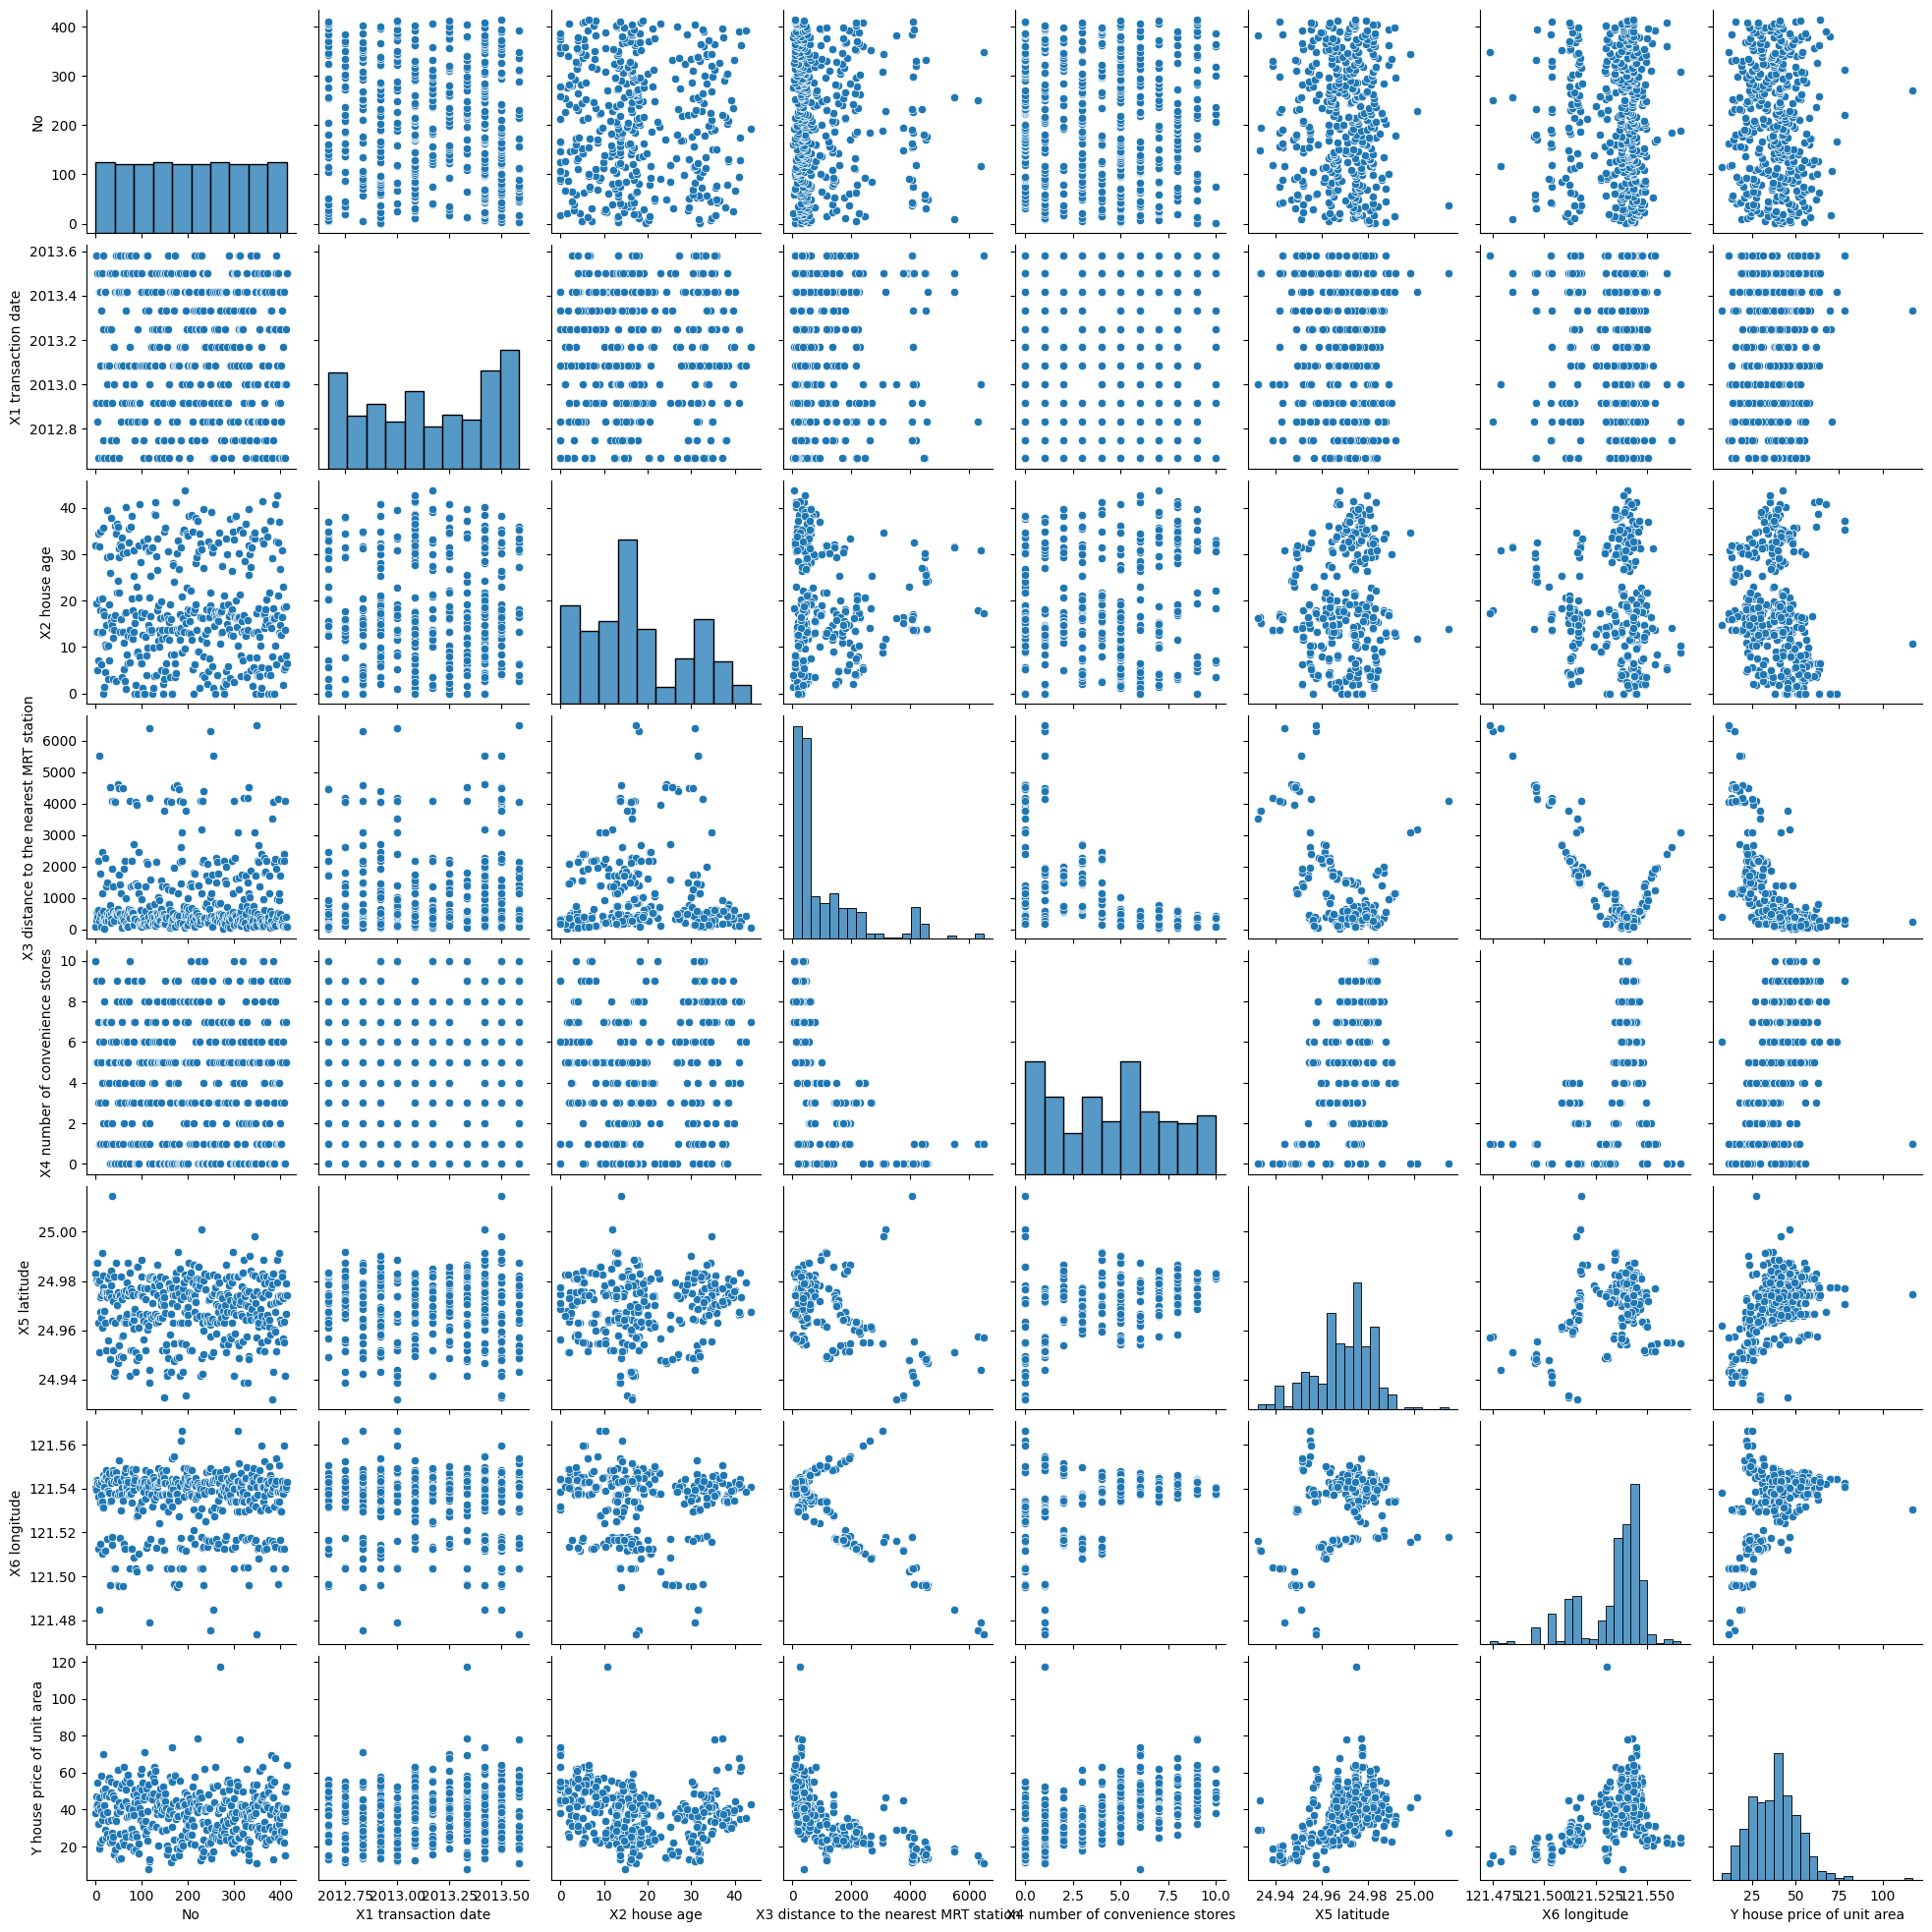

In [35]:
sns.pairplot(df)

training model

In [40]:
X = df.drop("Y house price of unit area", axis=1)
Y = df['Y house price of unit area']

In [41]:
print(X.shape , Y.shape)

(414, 7) (414,)


In [46]:
X_train, X_test , Y_train, Y_test= train_test_split(X,Y ,test_size=0.2,random_state=5)

In [47]:
X_train.shape

(331, 7)

In [49]:
X_test.shape

(83, 7)

In [50]:
model= LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
model.coef_

array([-4.48091648e-03,  5.10602017e+00, -3.05377642e-01, -4.84543767e-03,
        1.12915539e+00,  2.28530980e+02, -4.95972289e+01])

In [52]:
model.intercept_

np.float64(-9912.46699226917)

In [53]:
pd.DataFrame(model.coef_, X.columns, columns=['Coedicients'])

,Coedicients
No,-0.004481
X1 transaction date,5.106020
X2 house age,-0.305378
X3 distance to the nearest MRT station,-0.004845
X4 number of convenience stores,1.129155
X5 latitude,228.530980
X6 longitude,-49.597229


Prediction of our Model 

In [56]:
Y_pred = model.predict(X_test)

Evaluation Matrices

In [60]:
from sklearn import metrics
MAE= metrics.mean_absolute_error(Y_test, Y_pred)
MSE=metrics.mean_squared_error(Y_test, Y_pred)
RMSE= np.sqrt(MSE)

In [61]:
MAE

5.558171415722082

In [62]:
MSE

58.633821095995316

In [63]:
RMSE

np.float64(7.657272431877772)

In [70]:
df['Y house price of unit area'].mean()

np.float64(37.980193236714975)

In [71]:
test_residuals= Y_test- Y_pred


In [74]:
Y_pred

array([37.94588235, 46.84105144, 35.75007504, 32.79594943, 42.82861507,
       44.48055438, 52.82718833, 48.26553242, 35.29402613, 36.9810308 ,
       40.79148169, 34.0794296 , 42.62254758, 38.49236427, 54.79335797,
       38.47762453, 43.60049252, 41.26490193, 51.09475415, 50.6368343 ,
       40.82076064, 15.77651144, 43.83390685, 47.82087977, 48.52976465,
       42.7260463 , 40.48000445, 36.95019389, 19.19904373, 43.36756085,
       47.24988204, 34.51405951, 36.06592188, 55.0653277 , 36.75163872,
       12.99522787, 44.4036653 , 45.75945932, 36.76523791, 41.79746987,
       36.41643832, 36.3204185 , 34.6609248 , 44.42759795, 48.14701613,
       40.35013798, 30.77606141, 39.64948775, 40.32041203, 39.08557727,
       12.03853125, 42.2688639 , 41.8500757 , 11.8226938 , 10.16403782,
       40.44490315, 37.83242716, 36.57420341, 39.67626976, 31.83039249,
       43.15928194, 24.51006658, 54.26797924, 31.35273753, 30.97784833,
       28.64993129, 38.74802544, 46.13819367, 39.3989792 , 40.13

Text(0, 0.5, 'Y house price of unit area')

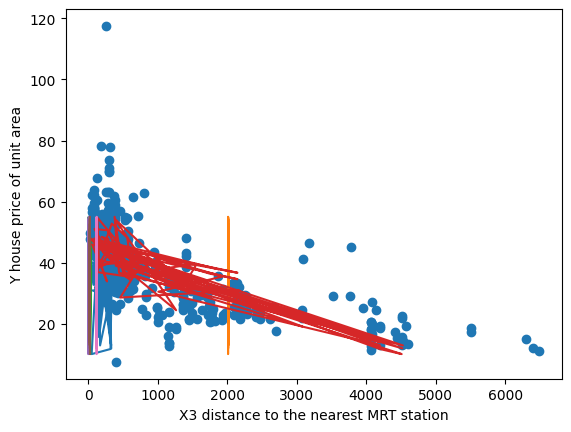

In [76]:
plt.scatter(df['X3 distance to the nearest MRT station'], df['Y house price of unit area'])
plt.plot(X_test, model.predict(X_test))
plt.xlabel('X3 distance to the nearest MRT station')
plt.ylabel('Y house price of unit area')